In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, BertModel
from sklearn.model_selection import train_test_split
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, accuracy_score
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [2]:
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
THRESHOLD = 0.60 # originally 0.5. modulated by ishani to minimize false positives at the expense of accuracy.

In [4]:
# Positive: your matched LGBTQ+ bills
lgbtq = pd.read_csv('/content/drive/MyDrive/capstone_personal/matched_lgbtq_bills.csv') # (changed file path slightly)
lgbtq['label_id'] = 1

# Negative: random sample from unmatched LegiScan bills
all_bills = pd.read_csv('/content/drive/MyDrive/capstone_personal/all_bills_2021_2026.csv',
    engine='python', # ishanis edits
    on_bad_lines='skip',) # ishanis edits — added b/c of error below
    # ParserError: Error tokenizing data. C error: Expected 27 fields in line 70638, saw 29

non_lgbtq = all_bills[~all_bills['bill_id'].isin(lgbtq['bill_id'])].sample(
    n=len(lgbtq) * 2,
    random_state=42
)
non_lgbtq['label_id'] = 0

df = pd.concat([lgbtq, non_lgbtq]).sample(frac=1, random_state=42)
df['text'] = df['title'].fillna('') + '. ' + df['description'].fillna('')


Deriving some meta-data...

In [5]:
df['year'] = pd.to_datetime(df['status_date']).dt.year
df['year'] = df['year'].fillna(df['year']).astype('Int64')

In [6]:
def parse_party_counts(party_str):
    """Parse 'R | D | R | R' into party counts."""
    if pd.isna(party_str):
        return {'R': 0, 'D': 0, 'Other': 0}

    parties = [p.strip() for p in str(party_str).split('|')]
    counts = {
        'R': sum(1 for p in parties if p == 'R'),
        'D': sum(1 for p in parties if p == 'D'),
        'Other': sum(1 for p in parties if p not in ('R', 'D'))
    }
    return counts

# Apply and expand into columns
party_counts = df['sponsor_parties'].apply(parse_party_counts).apply(pd.Series)
df['r_sponsors'] = party_counts['R']
df['d_sponsors'] = party_counts['D']
df['other_sponsors'] = party_counts['Other']


# Derive the dominant party for each bill
def dominant_party(row):
    if row['r_sponsors'] > row['d_sponsors']:
        return 'R'
    elif row['d_sponsors'] > row['r_sponsors']:
        return 'D'
    elif row['r_sponsors'] == 0 and row['d_sponsors'] == 0:
        return 'Other'
    else:
        return 'Bipartisan'


df['dominant_party'] = df.apply(dominant_party, axis=1)

In [7]:
# copied code from ambro for state lean

state_year_profiles = df.groupby(['state', 'year']).agg(
    # --- Volume ---
    total_bills=('bill_id', 'count'),

    # --- Partisan Sponsorship ---
    r_sponsored_bills=('dominant_party', lambda x: (x == 'R').sum()),
    d_sponsored_bills=('dominant_party', lambda x: (x == 'D').sum()),
    bipartisan_bills=('dominant_party',
                      lambda x: (x == 'Bipartisan').sum()),

    # --- Pass Rates ---
    # total_passed=('passed', 'sum'),

    # --- Sponsor Counts (avg engagement) ---
    avg_sponsor_count=('sponsor_count', 'mean'),
    avg_action_count=('action_count', 'mean'),
).reset_index()

# --- Derived Ratios ---

# Partisan lean: ratio of R-sponsored to total partisan bills
# Values > 0.5 = R-leaning legislature, < 0.5 = D-leaning
state_year_profiles['partisan_bills'] = (
    state_year_profiles['r_sponsored_bills'] +
    state_year_profiles['d_sponsored_bills']
)
state_year_profiles['state_r_sponsorship_ratio'] = (
    state_year_profiles['r_sponsored_bills'] /
    state_year_profiles['partisan_bills']
).fillna(0.5)  # Handle edge cases

# # Overall pass rate
# state_year_profiles['overall_pass_rate'] = (
#     state_year_profiles['total_passed'] /
#     state_year_profiles['total_bills']
# )

# Bipartisan ratio: what fraction of bills have mixed sponsorship
state_year_profiles['bipartisan_ratio'] = (
    state_year_profiles['bipartisan_bills'] /
    state_year_profiles['total_bills']
)

print("\n--- State-Year Profile Sample ---")
cols = ['state', 'year', 'total_bills', 'state_r_sponsorship_ratio',
        'bipartisan_ratio']
print(state_year_profiles[cols].head(10).to_string(index=False))


--- State-Year Profile Sample ---
state  year  total_bills  state_r_sponsorship_ratio  bipartisan_ratio
   AK  2021            2                   0.000000               0.0
   AK  2022            4                   0.666667               0.0
   AK  2023            5                   1.000000               0.0
   AK  2024            3                   1.000000               0.0
   AK  2025            2                   1.000000               0.0
   AL  2021           21                   0.857143               0.0
   AL  2022           11                   0.900000               0.0
   AL  2023            9                   0.888889               0.0
   AL  2024           12                   0.833333               0.0
   AL  2025           14                   0.923077               0.0


In [8]:
state_lean_2024 = (
    state_year_profiles
    .sort_values("year")
    .groupby("state")
    .tail(1)[["state", "year", "state_r_sponsorship_ratio"]]
)

In [9]:
print(state_lean_2024.isna().sum())

state                        0
year                         0
state_r_sponsorship_ratio    0
dtype: int64


In [10]:
state_lean_2024['state_R_leaning'] = state_lean_2024['state_r_sponsorship_ratio'] > 0.5

In [11]:
df = df.merge(
    state_lean_2024[['state', 'state_R_leaning', 'state_r_sponsorship_ratio']],
    on='state',
    how='left'
)

# maybe change later

In [12]:
lgbtq['year'] = lgbtq['session_year']
lgbtq['true_stance'] = lgbtq['label']


In [13]:
df['percent_yea'] = df['total_yea'] / (df['total_yea'] + df['total_nay'])
df['percent_nay'] = df['total_nay'] / (df['total_yea'] + df['total_nay'])

df['percent_yea'] = df['percent_yea'].fillna(0)
df['percent_nay'] = df['percent_nay'].fillna(0)

Defining train and test sets.

In [14]:

print(f"Total bills: {len(df)}")
print(f"  LGBTQ+:     {(df['label_id']==1).sum()}")
print(f"  Non-LGBTQ+: {(df['label_id']==0).sum()}")
print(f"\nSample text:\n{df['text'].iloc[0]}")

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label_id']
)
print(f"\nTrain: {len(train_df)} ({train_df['label_id'].mean():.1%} LGBTQ+)")
print(f"Test:  {len(test_df)} ({test_df['label_id'].mean():.1%} LGBTQ+)")

Total bills: 6120
  LGBTQ+:     2040
  Non-LGBTQ+: 4080

Sample text:
Revise reimbursement for medicaid services. Revise reimbursement for medicaid services

Train: 4896 (33.3% LGBTQ+)
Test:  1224 (33.3% LGBTQ+)


In [15]:
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = BertModel.from_pretrained(MODEL_NAME).to(device)

# Quick sanity check
test_inputs = tokenizer("An act prohibiting gender transition procedures for minors",
                       return_tensors="pt").to(device)
test_outputs = base_model(**test_inputs)
print(f"LegalBERT hidden size: {test_outputs.last_hidden_state.shape}")
# Should be [1, seq_len, 768]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

LegalBERT hidden size: torch.Size([1, 10, 768])


In [16]:
# 1. Token length distribution across ALL bills
token_lengths = []
for _, row in df.iterrows():
    text = str(row['text']).strip()
    if text:
        toks = tokenizer(text)['input_ids']
        token_lengths.append(len(toks))

token_lengths = np.array(token_lengths)

print("TOKEN LENGTH DISTRIBUTION")
print("=" * 50)
print(f"  Min:    {token_lengths.min()}")
print(f"  25th:   {np.percentile(token_lengths, 25):.0f}")
print(f"  Median: {np.percentile(token_lengths, 50):.0f}")
print(f"  75th:   {np.percentile(token_lengths, 75):.0f}")
print(f"  95th:   {np.percentile(token_lengths, 95):.0f}")
print(f"  Max:    {token_lengths.max()}")

# How many bills get truncated at each max_len?
for ml in [128, 256, 512]:
    truncated = (token_lengths > ml).sum()
    pct = truncated / len(token_lengths) * 100
    print(f"\n  max_len={ml}: {truncated}/{len(token_lengths)} bills truncated ({pct:.1f}%)")


# 2. Show a few examples: short, median, long
sorted_idx = np.argsort(token_lengths)
examples = {
    'Shortest': sorted_idx[0],
    'Median':   sorted_idx[len(sorted_idx)//2],
    'Longest':  sorted_idx[-1],
}

for name, idx in examples.items():
    row = df.iloc[idx]
    text = str(row['text']).strip()
    toks = tokenizer(text)['input_ids']
    decoded = tokenizer.convert_ids_to_tokens(toks)

    print(f"\n{'='*50}")
    print(f"{name} bill: {row.get('state','')} {row.get('bill_number','')} ({len(toks)} tokens)")
    print(f"Raw: {text[:200]}{'...' if len(text)>200 else ''}")
    print(f"Tokens: {' '.join(decoded[:40])}{'...' if len(decoded)>40 else ''}")

Token indices sequence length is longer than the specified maximum sequence length for this model (605 > 512). Running this sequence through the model will result in indexing errors


TOKEN LENGTH DISTRIBUTION
  Min:    7
  25th:   31
  Median: 49
  75th:   79
  95th:   187
  Max:    9489

  max_len=128: 625/6120 bills truncated (10.2%)

  max_len=256: 156/6120 bills truncated (2.5%)

  max_len=512: 43/6120 bills truncated (0.7%)

Shortest bill: MO HB10 (7 tokens)
Raw: APPROPRIATION BILL. APPROPRIATION BILL
Tokens: [CLS] appropriation bill . appropriation bill [SEP]

Median bill: NJ A1318 (49 tokens)
Raw: Provides for excused absences for public school students involved in election activities on day of general election under certain circumstances.. Provides for excused absences for public school studen...
Tokens: [CLS] provides for excuse ##d absence ##s for public school students involved in election activities on day of general election under certain circumstances . . provides for excuse ##d absence ##s for public school students involved in election activities on...

Longest bill: OH HB96 (9489 tokens)
Raw: Make state operating appropriations for FY 2026-27. To a

In [17]:
class BillDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data = []
        for _, row in dataframe.iterrows():
            text = str(row['text']).strip()
            if not text:
                continue
            encoded = tokenizer(
                text,
                return_tensors='pt',
                max_length=max_len,
                truncation=True,
                padding='max_length',
            )
            self.data.append({
                'input_ids': encoded['input_ids'].squeeze(0).to(device),
                'attention_mask': encoded['attention_mask'].squeeze(0).to(device),
                'label': torch.tensor(row['label_id'], dtype=torch.float32, device=device),
            })
        print(f"  Loaded {len(self.data)} examples")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


MAX_LEN = 256

print("Building train set...")
train_data = BillDataset(train_df, tokenizer, max_len=MAX_LEN)
print("Building test set...")
test_data = BillDataset(test_df, tokenizer, max_len=MAX_LEN)

Building train set...
  Loaded 4896 examples
Building test set...
  Loaded 1224 examples


In [18]:
class LegalBERTClassifier(torch.nn.Module):
    def __init__(self, bert_model, hidden_size=768, dropout=0.3):
        super().__init__()
        self.bert = bert_model
        self.dropout = torch.nn.Dropout(dropout)
        self.linear = torch.nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask=None):
        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        cls_output = bert_output[:, 0, :]
        cls_output = self.dropout(cls_output)
        logit = self.linear(cls_output)
        return torch.squeeze(logit)


model = LegalBERTClassifier(base_model).to(device)

# No class weighting needed — 2:1 ratio is mild enough
# loss_fn = torch.nn.BCEWithLogitsLoss()

# new loss_fn
# labels = torch.tensor([ex['label'] for ex in train_data], dtype=torch.float)  # adjust if needed
# n_pos = labels.sum()
# n_neg = labels.numel() - n_pos
# pos_weight = (n_neg / (n_pos + 1e-8)).to(device)   # ~ 97/3 = 32.33
# loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# print("pos_weight =", pos_weight.item())

# claude loss_fn
# Tune this: try 2.5, 3.0, 4.0
# 2.5 best for now (2.0 and 3.0 are objectively, all-around worse)
pos_weight = torch.tensor([3.0]).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)



BATCH_SIZE = 8
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

# Sanity check
batch = next(iter(train_loader))
out = model(batch['input_ids'], batch['attention_mask'])
loss = loss_fn(out, batch['label'])
print(f"Sanity check — output: {out.shape}, loss: {loss.item():.4f}")

Sanity check — output: torch.Size([8]), loss: 1.3112


In [19]:
def train_loop(dataloader, model, loss_fn, optimizer, reporting_interval=50):
    model.train()
    epoch_loss, total_batches = 0, 0

    for batch_idx, data in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(data['input_ids'], data['attention_mask'])
        loss = loss_fn(outputs, data['label'])
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total_batches += 1

        if (batch_idx + 1) % reporting_interval == 0:
            print(
                f"  Batch {batch_idx + 1}: avg loss = {epoch_loss / total_batches:.4f}")

    print(f"  Train loss: {epoch_loss / max(total_batches, 1):.4f}")


def eval_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for data in dataloader:
            outputs = model(data['input_ids'], data['attention_mask'])
            test_loss += loss_fn(outputs, data['label']).item()

            preds = (torch.sigmoid(outputs) >= THRESHOLD).float()  # replace torch.round(...)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(data['label'].cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(
        f"  Test loss: {test_loss / len(dataloader):.4f}, Accuracy: {100 * accuracy:.1f}%")
    print("\n" + classification_report(
        all_labels, all_preds,
        target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
    ))

In [20]:
for param in model.bert.parameters():
    param.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-4
)

print("Phase 1: Classifier head only\n")
for epoch in range(3):
    print(f"Epoch {epoch + 1}/3")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

# Phase 2: Unfreeze last 2 BERT layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Phase 2: Fine-tuning last 2 layers\n")
for epoch in range(2):
    print(f"Epoch {epoch + 1}/2")
    train_loop(train_loader, model, loss_fn, optimizer)
    eval_loop(test_loader, model, loss_fn)
    print()

print("Done!")

Phase 1: Classifier head only

Epoch 1/3
  Batch 50: avg loss = 1.1384
  Batch 100: avg loss = 1.1409
  Batch 150: avg loss = 1.1442
  Batch 200: avg loss = 1.1390
  Batch 250: avg loss = 1.1313
  Batch 300: avg loss = 1.1246
  Batch 350: avg loss = 1.1212
  Batch 400: avg loss = 1.1169
  Batch 450: avg loss = 1.1105
  Batch 500: avg loss = 1.1022
  Batch 550: avg loss = 1.0994
  Batch 600: avg loss = 1.0963
  Train loss: 1.0948
  Test loss: 1.0481, Accuracy: 68.1%

              precision    recall  f1-score   support

  non-LGBTQ+      0.775     0.734     0.754       816
      LGBTQ+      0.519     0.574     0.545       408

    accuracy                          0.681      1224
   macro avg      0.647     0.654     0.649      1224
weighted avg      0.690     0.681     0.684      1224


Epoch 2/3
  Batch 50: avg loss = 1.0529
  Batch 100: avg loss = 1.0576
  Batch 150: avg loss = 1.0454
  Batch 200: avg loss = 1.0308
  Batch 250: avg loss = 1.0321
  Batch 300: avg loss = 1.0299
  Batc

In [21]:
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for data in test_loader:
        outputs = model(data['input_ids'], data['attention_mask'])
        # Apply sigmoid to convert logits → probabilities
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(data['label'].cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

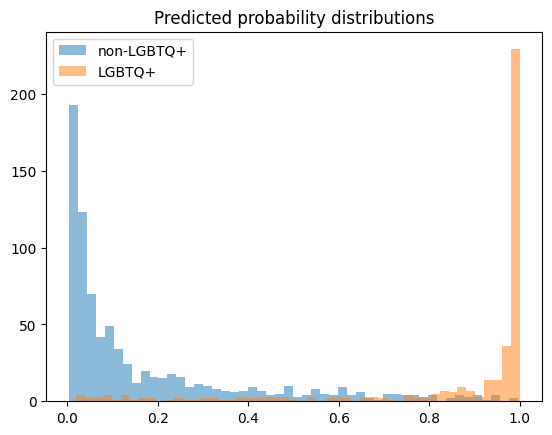

In [22]:
plt.hist(all_probs[all_labels==0], bins=50, alpha=0.5, label='non-LGBTQ+')
plt.hist(all_probs[all_labels==1], bins=50, alpha=0.5, label='LGBTQ+')
plt.legend()
plt.title("Predicted probability distributions")
plt.show()

In [23]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)

# F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best F1 threshold: {best_threshold:.3f}")

# Compare thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds = (all_probs >= t).astype(int)
    print(f"\nThreshold = {t}:")
    print(classification_report(all_labels, preds,
          target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3))

Best F1 threshold: 0.799

Threshold = 0.3:
              precision    recall  f1-score   support

  non-LGBTQ+      0.956     0.798     0.870       816
      LGBTQ+      0.696     0.926     0.795       408

    accuracy                          0.841      1224
   macro avg      0.826     0.862     0.832      1224
weighted avg      0.869     0.841     0.845      1224


Threshold = 0.4:
              precision    recall  f1-score   support

  non-LGBTQ+      0.948     0.846     0.894       816
      LGBTQ+      0.746     0.907     0.819       408

    accuracy                          0.866      1224
   macro avg      0.847     0.876     0.856      1224
weighted avg      0.881     0.866     0.869      1224


Threshold = 0.5:
              precision    recall  f1-score   support

  non-LGBTQ+      0.936     0.890     0.912       816
      LGBTQ+      0.799     0.877     0.836       408

    accuracy                          0.886      1224
   macro avg      0.867     0.884     0.874      

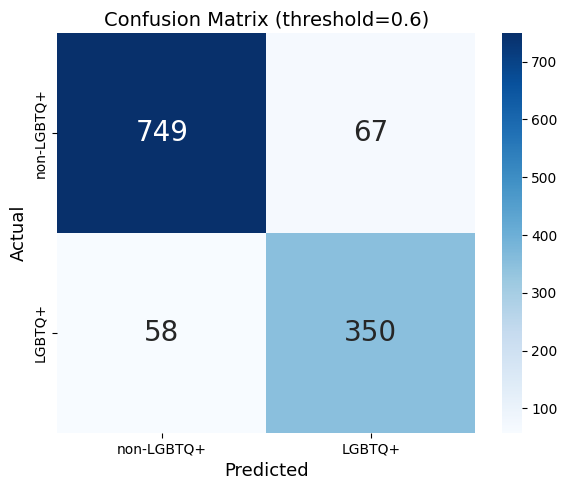

              precision    recall  f1-score   support

  non-LGBTQ+      0.928     0.918     0.923       816
      LGBTQ+      0.839     0.858     0.848       408

    accuracy                          0.898      1224
   macro avg      0.884     0.888     0.886      1224
weighted avg      0.899     0.898     0.898      1224



In [24]:
# 0.6 puts the accuracy > 90% while putting FP rate at ~3.3%. Seems like the right

all_preds = (all_probs >= THRESHOLD).astype(int)

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-LGBTQ+', 'LGBTQ+'],
            yticklabels=['non-LGBTQ+', 'LGBTQ+'],
            annot_kws={'size': 20}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()

print(classification_report(
    all_labels, all_preds,
    target_names=['non-LGBTQ+', 'LGBTQ+'], digits=3
))

In [25]:
import os, json
from pathlib import Path

SAVE_DIR = Path("/saved_models/lgbtq_relevance_legalbert_iteration")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# 1) save tokenizer
tokenizer.save_pretrained(SAVE_DIR)

# 2) save model weights + small metadata needed to rebuild the module
ckpt = {
    "model_state_dict": model.state_dict(),
    "base_model_name": MODEL_NAME,      # e.g. 'nlpaueb/legal-bert-base-uncased'
    "hidden_size": 768,
    "dropout": 0.3,
}
torch.save(ckpt, SAVE_DIR / "relevance_model_iteration.pt")

print(f"Saved relevance model to: {SAVE_DIR.resolve()}")

Saved relevance model to: /saved_models/lgbtq_relevance_legalbert_iteration


In [ ]:
all_preds

# Stance

In [26]:
train_df.columns

Index(['state', 'bill_id', 'session_id', 'bill_number', 'status',
       'status_desc', 'status_date', 'title', 'description', 'committee_id',
       'committee', 'last_action_date', 'last_action', 'url', 'state_link',
       'sponsor_names', 'sponsor_parties', 'primary_sponsor', 'sponsor_count',
       'action_count', 'last_history_action', 'document_count', 'document_id',
       'document_type', 'document_url', 'rollcall_count', 'total_yea',
       'total_nay', 'year', 'r_sponsors', 'd_sponsors', 'other_sponsors',
       'bill_dominant_party', 'passed', 'failed', 'vetoed', 'state_lean',
       'r_sponsorship_ratio', 'pass_rate_gap', 'overall_pass_rate',
       'bipartisan_ratio', 'session_year', 'label', 'label_source', 'label_id',
       'document_types', 'document_urls', 'text', 'dominant_party',
       'state_R_leaning', 'state_r_sponsorship_ratio', 'percent_yea',
       'percent_nay'],
      dtype='object')

In [27]:
train_df['label']

,label
2746,NaN
648,harmful
2305,NaN
4706,NaN
2659,harmful
...,...
4422,harmful
4239,NaN
834,harmful
3916,NaN


In [28]:
features = [
    'state_r_sponsorship_ratio',
    'dominant_party',
    # 'state_R_leaning',
    # 'total_yea',
    # 'total_nay',
    'percent_nay',
    'r_sponsors',
    'd_sponsors',
    'other_sponsors',
]

train_df['true_stance'] = train_df['label']
train_df['is_lgbtq'] = train_df['label_id']

# Select a subset of columns
df_subset = train_df.loc[
          train_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ]

df_subset['true_stance'] = (df_subset['true_stance'] == 'harmful').astype(int)

if 'dominant_party' in df_subset.columns:
    df_subset['dominant_party'] = (df_subset['dominant_party'] == 'R').astype(int)

print(df_subset)

      state_r_sponsorship_ratio  dominant_party  percent_nay  r_sponsors  \
648                    0.633803               1     0.000000           5   
2659                   0.000000               1     0.000000           5   
5128                   0.750000               1     0.000000          19   
643                    0.791667               1     0.179688           2   
296                    0.797688               1     0.000000          40   
...                         ...             ...          ...         ...   
1383                   0.560000               0     0.000000           2   
5830                   0.797688               1     0.529483          95   
1073                   1.000000               0     0.000000           0   
4422                   0.111111               1     0.000000           3   
834                    1.000000               1     0.000000           1   

      d_sponsors  other_sponsors  true_stance  
648            0               0       

In [29]:
# test version

test_df['true_stance'] = test_df['label']
test_df['is_lgbtq'] = test_df['label_id']

# Select a subset of columns
df_subset_test = test_df.loc[
          test_df['is_lgbtq'] == 1,
          features + ['true_stance']
      ]

df_subset_test['true_stance'] = (df_subset_test['true_stance'] == 'harmful').astype(int)

if 'dominant_party' in df_subset_test.columns:
    df_subset_test['dominant_party'] = (df_subset_test['dominant_party'] == 'R').astype(int)

print(df_subset_test)

      state_r_sponsorship_ratio  dominant_party  percent_nay  r_sponsors  \
580                    1.000000               1     0.076190          40   
3949                   0.797688               0     0.000000           0   
2700                   1.000000               0     0.000000           0   
4057                   0.285714               1     0.000000           4   
4646                   0.966667               1     0.000000           1   
...                         ...             ...          ...         ...   
2617                   1.000000               1     0.000000           5   
1650                   0.797688               1     0.355263           9   
1777                   0.857143               1     0.439024           1   
4565                   1.000000               1     0.000000          34   
4735                   0.750000               1     0.288462          12   

      d_sponsors  other_sponsors  true_stance  
580            2               0       

In [30]:
# fix so train are the same
# X = df_subset.drop(columns='true_stance')
# y = df_subset['true_stance']

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,          # 20% test set
#     stratify=y,             # keeps harmful/supportive proportions
#     random_state=42
# )

X_train = df_subset.drop(columns='true_stance')
y_train = df_subset['true_stance']

X_test = df_subset_test.drop(columns='true_stance')
y_test = df_subset_test['true_stance']



In [31]:
print(df_subset.isna().sum())

state_r_sponsorship_ratio    0
dominant_party               0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64


In [32]:
print(df_subset_test.isna().sum())

state_r_sponsorship_ratio    0
dominant_party               0
percent_nay                  0
r_sponsors                   0
d_sponsors                   0
other_sponsors               0
true_stance                  0
dtype: int64


In [33]:
model = LogisticRegression(max_iter=500) # max_iter = 1000 originally
# , class_weight='balanced'

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

In [34]:
y_pred = model.predict(X_test)

print('New linear stance model using state, sponsor, and voting metadata:\n')
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['supportive', 'harmful']))

New linear stance model using state, sponsor, and voting metadata:

Accuracy: 0.9558823529411765
              precision    recall  f1-score   support

  supportive       0.96      0.60      0.74        43
     harmful       0.96      1.00      0.98       365

    accuracy                           0.96       408
   macro avg       0.96      0.80      0.86       408
weighted avg       0.96      0.96      0.95       408



In [35]:
# print('Old binary stance model using only dominant party:\n')

# y_pred_prev = np.where(df_subset['dominant_party'] == 1, 1, 0)

# y_true = df_subset['true_stance']

# print("Accuracy:", accuracy_score(y_true, y_pred_prev))
# print(classification_report(y_true, y_pred_prev, target_names=['supportive', 'harmful']))

In [41]:
len(X_test)

408

In [40]:
len(all_preds)

1224

#Cumulative Test Accuracy Report
Results from both models hooked together

In [48]:
# Attach predictions to dataframe
test_df['relevant_pred'] = all_preds

# Select only bills predicted as LGBTQ-relevant
df_subset_test_final = test_df.loc[
    test_df['relevant_pred'] == 1,
    features + ['true_stance']
].copy()

# Convert stance to binary target
df_subset_test_final['true_stance'] = (df_subset_test_final['true_stance'] == 'harmful').astype(int)

# Convert dominant_party if present
if 'dominant_party' in df_subset_test_final.columns:
    df_subset_test_final['dominant_party'] = (df_subset_test_final['dominant_party'] == 'R').astype(int)

print(df_subset_test_final)

      state_r_sponsorship_ratio  dominant_party  percent_nay  r_sponsors  \
580                    1.000000               1     0.076190          40   
3949                   0.797688               0     0.000000           0   
2700                   1.000000               0     0.000000           0   
4057                   0.285714               1     0.000000           4   
1629                   1.000000               1     0.000000           3   
...                         ...             ...          ...         ...   
2617                   1.000000               1     0.000000           5   
1650                   0.797688               1     0.355263           9   
1777                   0.857143               1     0.439024           1   
4565                   1.000000               1     0.000000          34   
4735                   0.750000               1     0.288462          12   

      d_sponsors  other_sponsors  true_stance  
580            2               0       

In [50]:
test_df['true_cumulative_label'] = np.where(
    test_df['is_lgbtq'] == True,
    test_df['true_stance'],
    "not applicable"
)

In [51]:
X_test_final = df_subset_test_final.drop(columns='true_stance')
y_test_final = df_subset_test_final['true_stance']

stance_preds = model.predict(X_test_final)

In [56]:
test_df['pred_cumulative_label'] = "not applicable"

# Fill in stance predictions for relevant bills
test_df.loc[test_df['relevant_pred'] == 1, 'pred_cumulative_label'] = stance_preds

test_df['pred_cumulative_label'] = test_df['pred_cumulative_label'].replace({
    1: 'harmful',
    0: 'supportive'
})

In [58]:
print(
    test_df[['relevant_pred','pred_cumulative_label']].head(10)
)

      relevant_pred pred_cumulative_label
361               0        not applicable
5547              0        not applicable
88                0        not applicable
4254              0        not applicable
580               1               harmful
3949              1            supportive
2743              0        not applicable
2700              1               harmful
4356              0        not applicable
4057              1               harmful


In [61]:
print('Combination Accuracy Assessment of relevance and stance models:\n')
print("Accuracy:", accuracy_score(test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']))
print(classification_report(
        test_df['true_cumulative_label'],
        test_df['pred_cumulative_label']
    ))

Combination Accuracy Assessment of relevance and stance models:

Accuracy: 0.8839869281045751
                precision    recall  f1-score   support

       harmful       0.83      0.87      0.85       365
not applicable       0.93      0.92      0.92       816
    supportive       0.45      0.40      0.42        43

      accuracy                           0.88      1224
     macro avg       0.74      0.73      0.73      1224
  weighted avg       0.88      0.88      0.88      1224

